In [6]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")


# RISE Data Science Practicum
## Week 2, Day 1 — Visualization with Matplotlib

**Goal for today:** Learn how to turn raw scientific numbers into clear, professional visual figures. We will break down how Matplotlib structures a plot, practice generating three fundamental chart types, and learn how to format our graphics so that external researchers can immediately understand our results.

**Estimated time:** ~50 minutes

### How to use this notebook
- Run each cell in order (`Shift + Enter`).
- Read through the fully solved examples carefully to understand the structure before creating your own plots.

---

## 1. Anatomy of a Matplotlib Plot

The most common point of confusion for beginners using Python's core plotting library, `matplotlib`, is the structural difference between a **Figure** and an **Axes**. 

* **Figure:** This is the overall canvas or window where everything is drawn. It can contain one or more independent charts, a background, a global title, and space configurations. Think of it as the picture frame.
* **Axes (or Subplot):** This is the actual chart within the figure where your numbers are plotted. It contains the coordinate grid, the x-axis, the y-axis, data lines, tick marks, and labels. A single figure can hold multiple axes, but an axes can only belong to one figure.



Let's import the standard visualization toolkit alias `plt` and build an explicit canvas structure to observe this object hierarchy.

Object type for 'fig': <class 'matplotlib.figure.Figure'>
Object type for 'ax': <class 'matplotlib.axes._axes.Axes'>


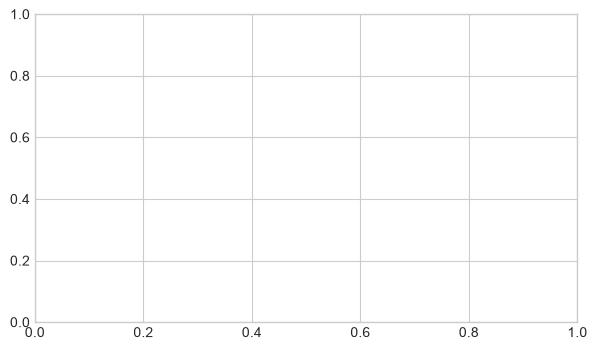

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a Figure (the canvas) and an Axes (the actual chart) explicitly
fig, ax = plt.subplots(figsize=(7, 4))

# 2. Print out the data types of these objects to confirm what they are
print(f"Object type for 'fig': {type(fig)}")
print(f"Object type for 'ax': {type(ax)}")

# Show the blank canvas space
plt.show()

## 2. Common Chart Types


Using the `ax` object we just isolated, we can display our data arrays using different visual formats depending on our scientific objective:
- **Line Plots (`ax.plot`):** Best for showing continuous trends over time.
- **Bar Charts (`ax.bar`):** Best for comparing discrete numbers across distinct categories.
- **Scatter Plots (`ax.scatter`):** Best for looking for relationships or correlations between two different variables.

Let's explore a synthetic weather observation dataset from our research station to practice all three.

### Line Plots


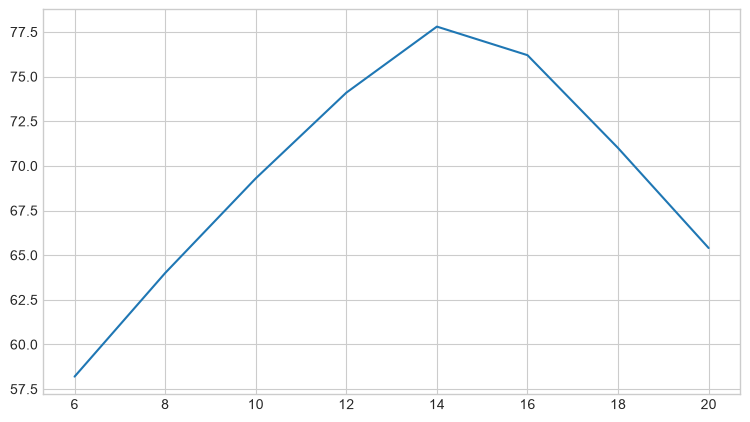

In [ ]:
#We start with nothing but our raw datasets. We will open a canvas (`fig` and `ax1`) and draw a single, default line for Station Alpha's temperature.

hours = [6, 8, 10, 12, 14, 16, 18, 20]
temp_station_alpha = [58.2, 64.0, 69.3, 74.1, 77.8, 76.2, 71.0, 65.4]

# Create the basic layout
fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot the base data track
ax1.plot(hours, temp_station_alpha)

plt.show()

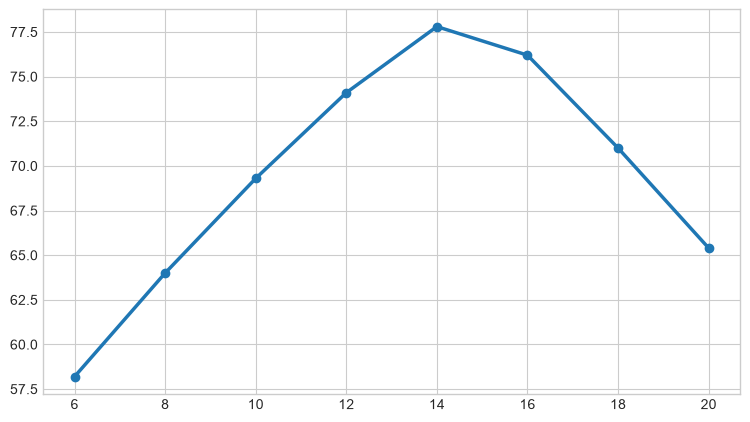

In [9]:
#Step 2: Adding Visual Separation & Style
# A raw line is hard to read. Now we add a professional style sheet (`seaborn-v0_8-whitegrid`) and customize our line with a specific color, line style (solid), marker points, and a label for our future legend.
# Notice we add a global theme at the very top
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax1 = plt.subplots(figsize=(9, 5))

# Addition: color, linestyle, marker, and label
ax1.plot(hours, temp_station_alpha, color='#1f77b4', linestyle='-', marker='o', linewidth=2.5, label='Station Alpha (Temp)')

plt.show()

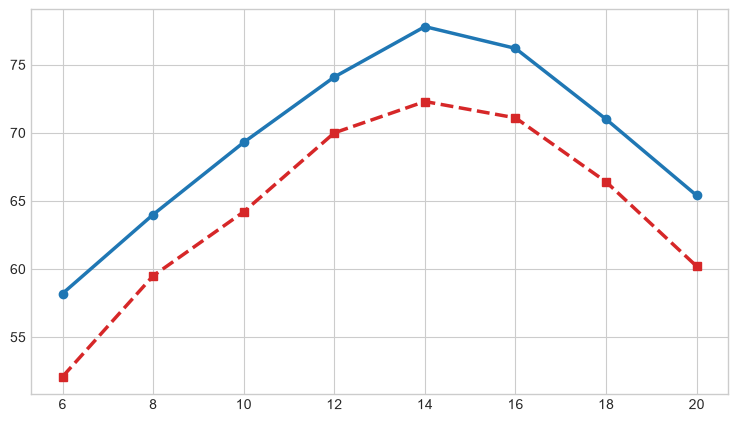

In [10]:
#Step 3: Layering a Second Dataset
#To compare locations, we add a second line for Station Beta. We intentionally change its color and turn the line style into dashes (`'--'`) with square markers (`'s'`) so they look completely distinct.
temp_station_beta = [52.1, 59.5, 64.2, 70.0, 72.3, 71.1, 66.4, 60.2]

fig, ax1 = plt.subplots(figsize=(9, 5))

# Line 1 from before
ax1.plot(hours, temp_station_alpha, color='#1f77b4', linestyle='-', marker='o', linewidth=2.5, label='Station Alpha (Temp)')

# Addition: Line 2 with separate tracking styles
ax1.plot(hours, temp_station_beta, color='#d62728', linestyle='--', marker='s', linewidth=2.5, label='Station Beta (Temp)')

plt.show()

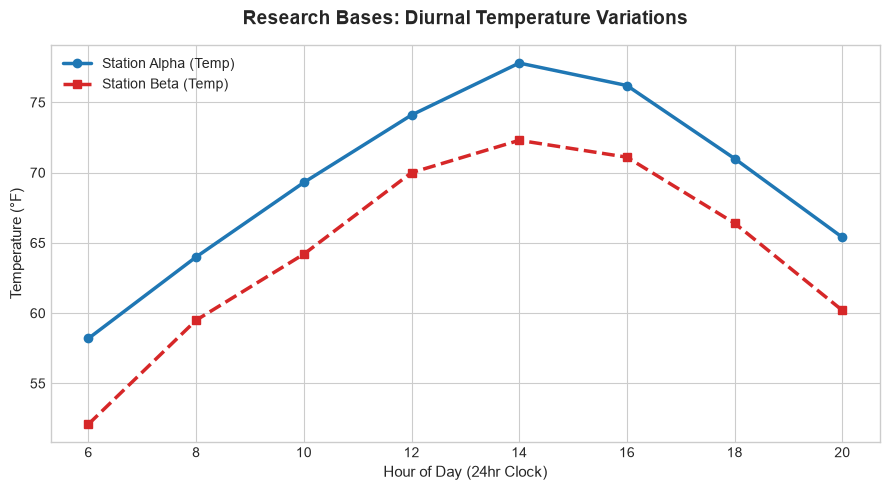

In [12]:
### Step 4: Communication (Labels, Title, and Legend)
#Now we make our chart standalone and scientific by adding an explicit title, naming both axes, and calling the `.legend()` function to display our custom labels.

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(hours, temp_station_alpha, color='#1f77b4', linestyle='-', marker='o', linewidth=2.5, label='Station Alpha (Temp)')
ax1.plot(hours, temp_station_beta, color='#d62728', linestyle='--', marker='s', linewidth=2.5, label='Station Beta (Temp)')

# Addition: Communication labels
ax1.set_title("Research Bases: Diurnal Temperature Variations", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Hour of Day (24hr Clock)", fontsize=11)
ax1.set_ylabel("Temperature (°F)", fontsize=11)

# Addition: Display the metadata box
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

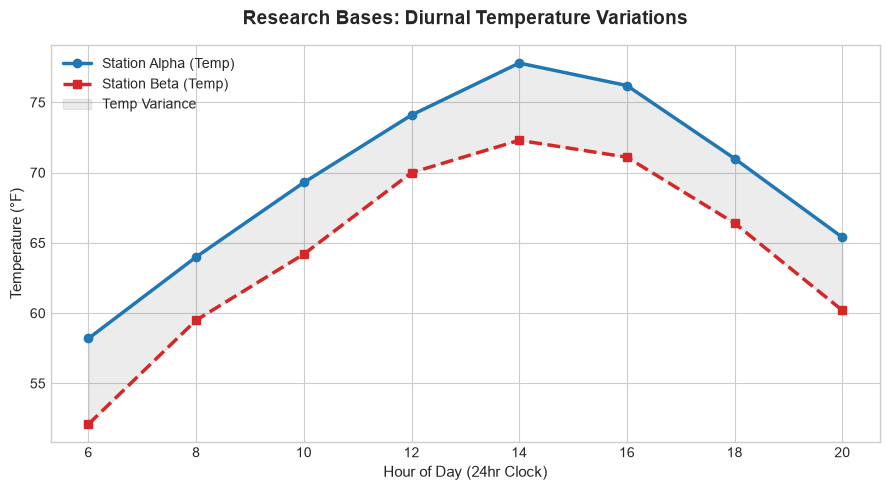

In [16]:
### Step 5: Highlighting Variance (Shading Regions)
#To emphasize the difference between the two environments, we can fill the space between our lines using `ax1.fill_between()`. We will use a soft grey color and low opacity (`alpha=0.15`).

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(hours, temp_station_alpha, color='#1f77b4', linestyle='-', marker='o', linewidth=2.5, label='Station Alpha (Temp)')
ax1.plot(hours, temp_station_beta, color='#d62728', linestyle='--', marker='s', linewidth=2.5, label='Station Beta (Temp)')

# Addition: Shade the gap between our two lines
ax1.fill_between(hours, temp_station_alpha, temp_station_beta, color='gray', alpha=0.15, label='Temp Variance') #---> addition

ax1.set_title("Research Bases: Diurnal Temperature Variations", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Hour of Day (24hr Clock)", fontsize=11)
ax1.set_ylabel("Temperature (°F)", fontsize=11)
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

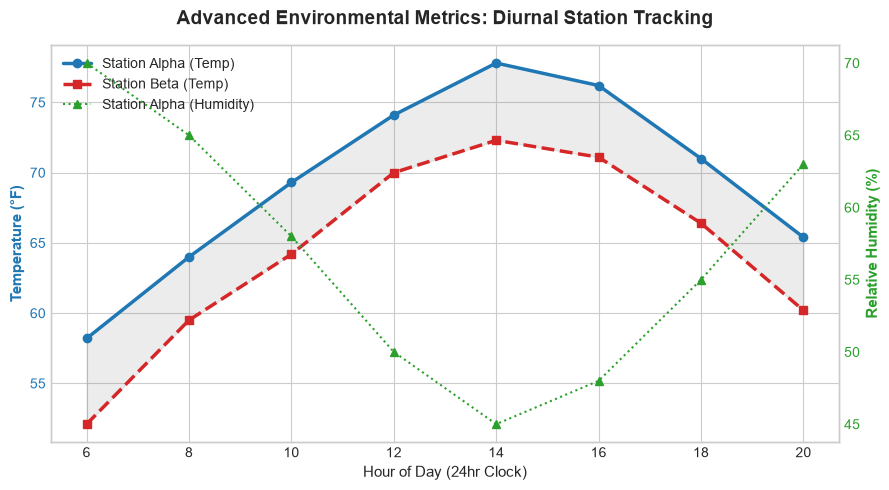

In [15]:
### Step 6: Advanced Layout (The Secondary Twin Y-Axis)
#What if we want to show Relative Humidity (%) on the exact same chart? Humidity uses percentages, which don't fit on a Fahrenheit axis. We instantiate a secondary axis (`ax2`) using `.twinx()` to handle this entirely separate metric.

humidity_alpha = [70, 65, 58, 50, 45, 48, 55, 63]

fig, ax1 = plt.subplots(figsize=(9, 5))

# Existing Temperature layers
line1 = ax1.plot(hours, temp_station_alpha, color='#1f77b4', linestyle='-', marker='o', linewidth=2.5, label='Station Alpha (Temp)')
line2 = ax1.plot(hours, temp_station_beta, color='#d62728', linestyle='--', marker='s', linewidth=2.5, label='Station Beta (Temp)')
ax1.fill_between(hours, temp_station_alpha, temp_station_beta, color='gray', alpha=0.15, label='Temp Variance')

ax1.set_title("Advanced Environmental Metrics: Diurnal Station Tracking", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Hour of Day (24hr Clock)", fontsize=11)
ax1.set_ylabel("Temperature (°F)", color='#1f77b4', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4') # Color-match the text to the line!

# ------------------------------------------------------------
# Addition: Twin axis architecture
# ------------------------------------------------------------
ax2 = ax1.twinx()  # Share the x-axis, create new y-axis on the right
line3 = ax2.plot(hours, humidity_alpha, color='#2ca02c', linestyle=':', marker='^', label='Station Alpha (Humidity)')

ax2.set_ylabel("Relative Humidity (%)", color='#2ca02c', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.grid(False) # Turn off right grid so it doesn't cross over the left grid

# Note: Because we have two axes, we combine their legends manually here:
all_plots = line1 + line2 + line3
all_labels = [p.get_label() for p in all_plots]
ax1.legend(all_plots, all_labels, loc='upper left')

plt.tight_layout()
plt.show()

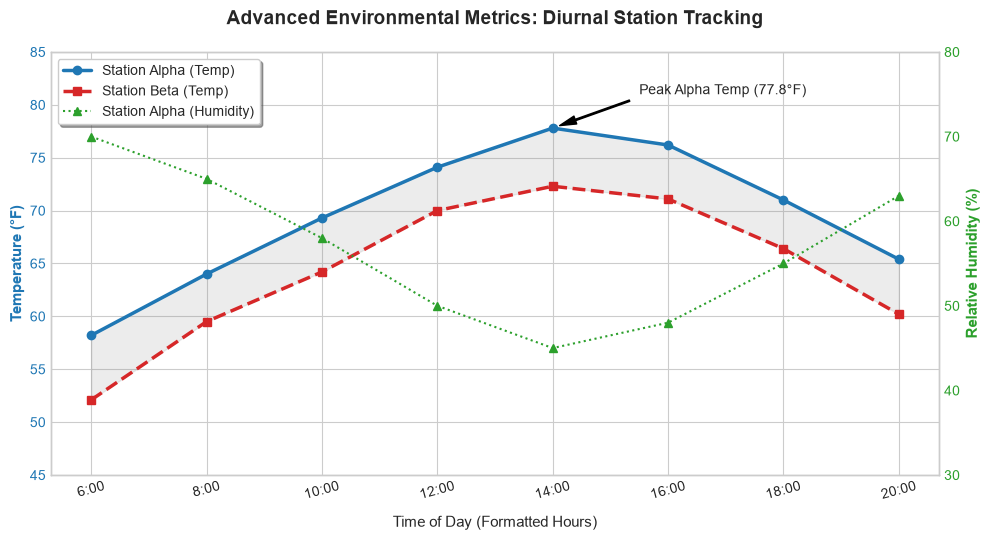

In [17]:
### Step 7: Final Polish (Reference Thresholds & Annotations)
#As our final master step, we clean up the X-axis tick format (turning `6, 8` into `6:00, 8:00`) and use `ax1.annotate()` to draw a deliberate arrow highlighting the exact peak temperature point on the chart.
fig, ax1 = plt.subplots(figsize=(10, 5.5))

line1 = ax1.plot(hours, temp_station_alpha, color='#1f77b4', linestyle='-', marker='o', linewidth=2.5, label='Station Alpha (Temp)')
line2 = ax1.plot(hours, temp_station_beta, color='#d62728', linestyle='--', marker='s', linewidth=2.5, label='Station Beta (Temp)')
ax1.fill_between(hours, temp_station_alpha, temp_station_beta, color='gray', alpha=0.15, label='Temp Variance')

ax1.set_title("Advanced Environmental Metrics: Diurnal Station Tracking", fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel("Time of Day (Formatted Hours)", fontsize=11, labelpad=10)
ax1.set_ylabel("Temperature (°F)", color='#1f77b4', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_ylim(45, 85)

ax2 = ax1.twinx()  
line3 = ax2.plot(hours, humidity_alpha, color='#2ca02c', linestyle=':', marker='^', label='Station Alpha (Humidity)')
ax2.set_ylabel("Relative Humidity (%)", color='#2ca02c', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#2ca02c')
ax2.set_ylim(30, 80)
ax2.grid(False)

# ------------------------------------------------------------
# Addition: X-axis Tick Modifications
# ------------------------------------------------------------
ax1.set_xticks(hours)
ax1.set_xticklabels([f"{h}:00" for h in hours], rotation=15)

# ------------------------------------------------------------
# Addition: Specific Arrow Annotation pointing directly at data coordinate (14, 77.8)
# ------------------------------------------------------------
ax1.annotate('Peak Alpha Temp (77.8°F)', 
             xy=(14, 77.8),            # The actual target point coordinates
             xytext=(15.5, 81),         # Where the text box will physically sit
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

# Build unified clean legend
all_plots = line1 + line2 + line3
all_labels = [p.get_label() for p in all_plots]
ax1.legend(all_plots, all_labels, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### Bar Chart

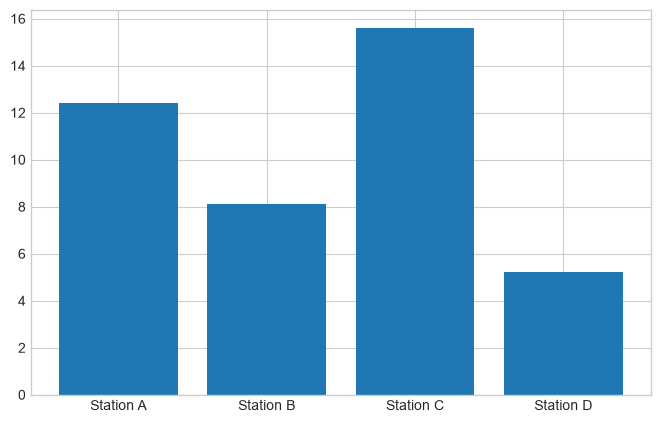

In [18]:
### Step 1: The Absolute Minimum Bar Chart
#We start by creating a simple bar chart to compare discrete numbers across different categories.
#We will open our canvas and map our research stations (`categories`) on the X-axis against their average wind speeds (`daily_avg_wind`) on the Y-axis.

categories = ['Station A', 'Station B', 'Station C', 'Station D']
daily_avg_wind = [12.4, 8.1, 15.6, 5.2]

# Create the basic layout
fig, ax = plt.subplots(figsize=(8, 5))

# Draw the base vertical bars
ax.bar(categories, daily_avg_wind)

plt.show()

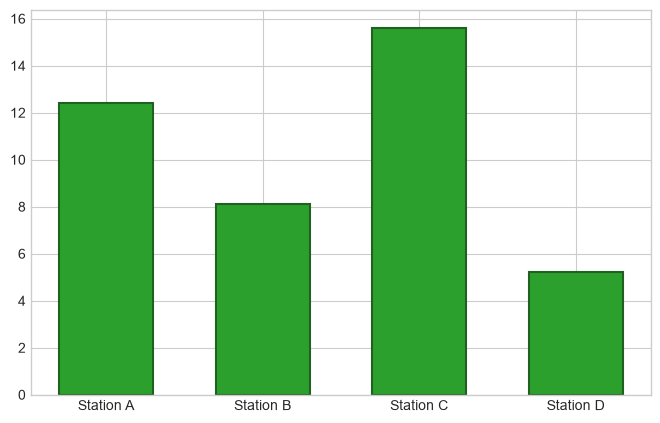

In [19]:
### Step 2: Styling Bars (Colors, Widths, and Borders)
#A plain blue chart looks generic. Now we apply a global style theme and use arguments within `ax.bar()` to change the bar colors to a custom teal hex code,
#adjust their width so they have breathing room, and add a dark edge border.

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))

# Addition: color, width, edgecolor, and linewidth
ax.bar(categories, daily_avg_wind, color='#2ca02c', width=0.6, edgecolor='#1e6120', linewidth=1.5)

plt.show()

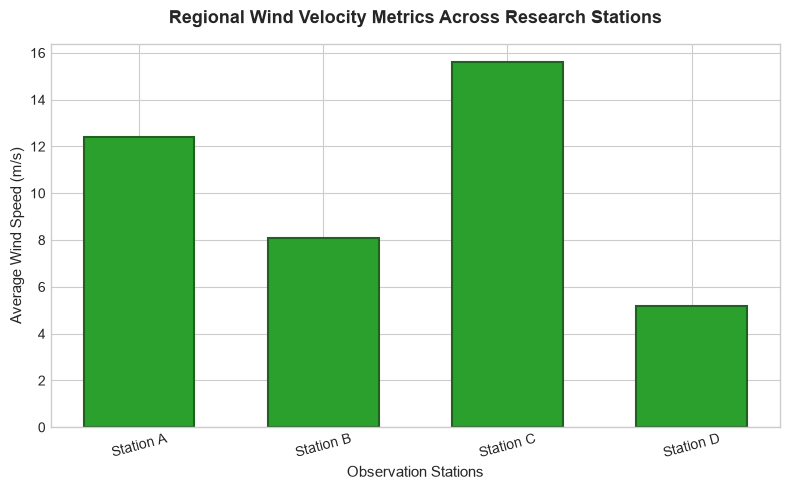

In [20]:
### Step 3: Clear Communication (Labels and Custom Ticks)
#Next, we make the chart scientifically meaningful.
#We add a descriptive title and name both axes with matching font properties. We also use `ax.tick_params` to rotate the x-axis labels slightly so they don't crowd each other if category names get long.

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(categories, daily_avg_wind, color='#2ca02c', width=0.6, edgecolor='#1e6120', linewidth=1.5)

# Addition: Titles, axis labels, and tick rotations
ax.set_title("Regional Wind Velocity Metrics Across Research Stations", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Observation Stations", fontsize=11)
ax.set_ylabel("Average Wind Speed (m/s)", fontsize=11)

ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

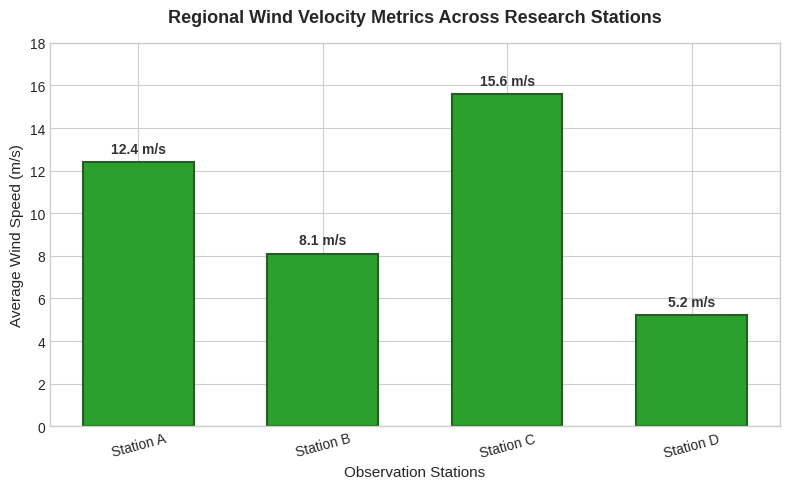

In [44]:
### Step 4: Adding Value Labels on Top of Bars (Annotation)
#In a bar chart, it can be hard for a viewer to guess the exact value of a bar just by looking at the Y-axis scale.
#We will use a `for` loop combined with `ax.text()` to programmatically print the exact numerical value right above the center of each bar.

fig, ax = plt.subplots(figsize=(8, 5))

# Store the bars in a variable to loop through them
bars = ax.bar(categories, daily_avg_wind, color='#2ca02c', width=0.6, edgecolor='#1e6120', linewidth=1.5)

ax.set_title("Regional Wind Velocity Metrics Across Research Stations", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Observation Stations", fontsize=11)
ax.set_ylabel("Average Wind Speed (m/s)", fontsize=11)
ax.tick_params(axis='x', rotation=15)

# ------------------------------------------------------------
# Addition: Dynamically labeling the height of each individual bar
# ------------------------------------------------------------
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.0,  # X-coordinate: center of the bar
        height + 0.3,                       # Y-coordinate: just slightly above the top of the bar
        f"{height} m/s",                    # Text string to display
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333'
    )

# Give a little extra padding at the top of the Y-axis so the text labels fit comfortably
ax.set_ylim(0, 18)

plt.tight_layout()
plt.show()

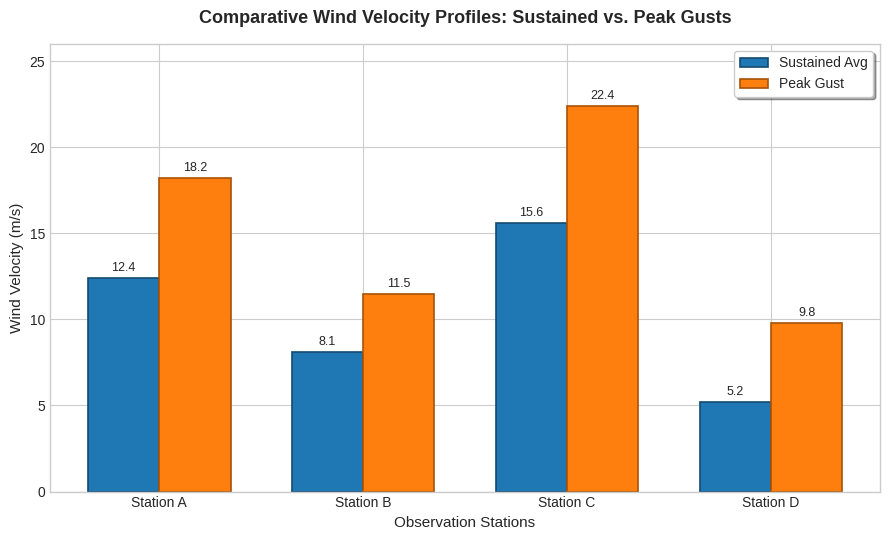

In [45]:
### Step 5: Advanced Concept (Grouped Side-by-Side Bars)
#What if we want to compare two different metrics per station side-by-side (e.g., Average Wind vs. Peak Wind Gusts)? 

#To do this, we cannot just call `ax.bar` twice or they will stack directly on top of each other and hide the data.
#We use `numpy` to manipulate index positions on the X-axis, shifting the first set of bars slightly to the left, and the second set slightly to the right.

import numpy as np

categories = ['Station A', 'Station B', 'Station C', 'Station D']
daily_avg_wind = [12.4, 8.1, 15.6, 5.2]
peak_wind_gusts = [18.2, 11.5, 22.4, 9.8] # New dataset to compare

# 1. Create mathematical numerical positions for our categories
x_indexes = np.arange(len(categories)) 
bar_width = 0.35  # Set an explicit width for each bar chunk

fig, ax = plt.subplots(figsize=(9, 5.5))

# ------------------------------------------------------------
# Addition: Grouped Shifted Bar Architecture
# ------------------------------------------------------------
# Plot first dataset shifted LEFT by half the bar width
bars1 = ax.bar(x_indexes - bar_width/2, daily_avg_wind, width=bar_width, 
               color='#1f77b4', edgecolor='#134a70', linewidth=1.2, label='Sustained Avg')

# Plot second dataset shifted RIGHT by half the bar width
bars2 = ax.bar(x_indexes + bar_width/2, peak_wind_gusts, width=bar_width, 
               color='#ff7f0e', edgecolor='#a85207', linewidth=1.2, label='Peak Gust')

# 2. Overwrite the raw numeric X-indexes back to readable text labels
ax.set_xticks(x_indexes)
ax.set_xticklabels(categories)

# 3. Add text labels to both sets of bars using a reusable labeling pattern
for b1, b2 in zip(bars1, bars2):
    ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.4, f"{b1.get_height()}", ha='center', fontsize=9)
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.4, f"{b2.get_height()}", ha='center', fontsize=9)

# Formatting polish
ax.set_title("Comparative Wind Velocity Profiles: Sustained vs. Peak Gusts", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Observation Stations", fontsize=11)
ax.set_ylabel("Wind Velocity (m/s)", fontsize=11)
ax.set_ylim(0, 26)
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### Scatter Plot
A scatter plot maps coordinates ($x, y$) to find relationships, correlations, or natural groupings (clusters) between two different continuous variables. We start by initializing our canvas and mapping an environmental metric: Temperature on the X-axis vs. Relative Humidity on the Y-axis.

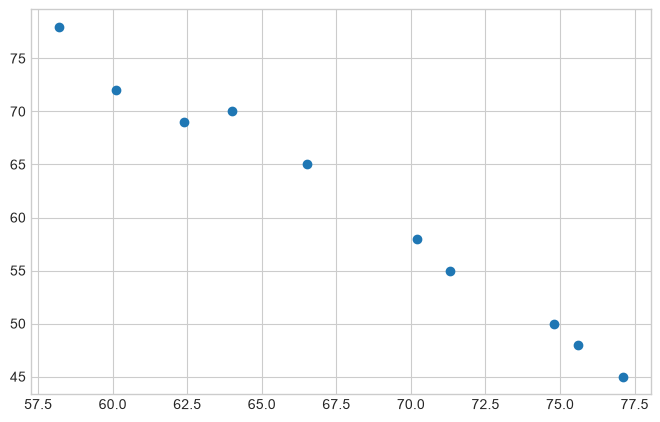

In [22]:
# Dataset 1: Environmental Readings
temp = [64.0, 66.5, 70.2, 74.8, 77.1, 75.6, 71.3, 58.2, 60.1, 62.4]
humidity = [70, 65, 58, 50, 45, 48, 55, 78, 72, 69]

# Create the basic layout
fig, ax = plt.subplots(figsize=(8, 5))

# Draw a standard scatter plot
ax.scatter(temp, humidity)

plt.show()

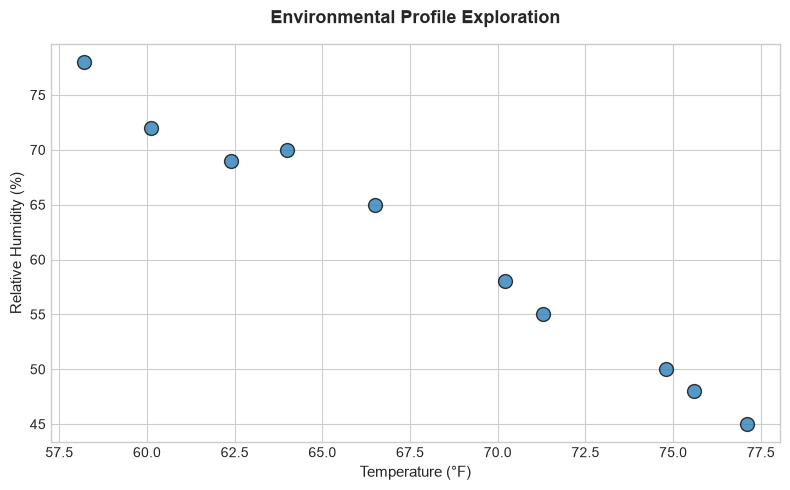

In [23]:
#To make individual data coordinates easier to isolate visually, we apply a global stylesheet theme.
#We can then use arguments inside `ax.scatter()` to increase the point markers size (`s=100`), switch to a custom color, and add transparency (`alpha=0.7`) which is crucial for seeing overlapping data points.

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))

# Addition: s (size), color, marker, and alpha (transparency)
ax.scatter(temp, humidity, s=100, color='#1f77b4', marker='o', alpha=0.75, edgecolor='black', linewidth=1)

# Adding fundamental labels
ax.set_title("Environmental Profile Exploration", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Temperature (°F)", fontsize=11)
ax.set_ylabel("Relative Humidity (%)", fontsize=11)

plt.tight_layout()
plt.show()

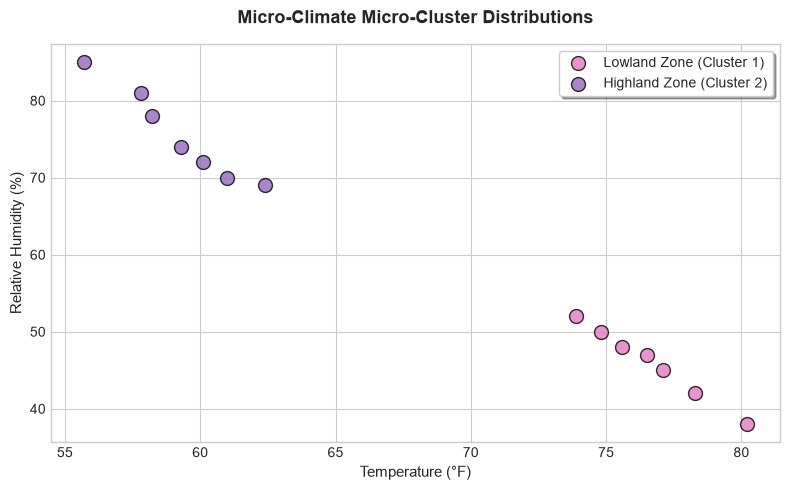

In [24]:
### Visualizing Distinct Data Clusters
#Data science workflows often involve identifying separated groupings or clusters within a dataset (e.g., distinguishing between different localized climate zones).
#To display two different clusters on the same plot, we can execute `ax.scatter()` twice in the same cell.
#By passing distinct coordinates, colors, and labels, Matplotlib automatically maps them as independent groups.

# Cluster 1: Lowland Station readings (Warm & Dry)
lowland_temp = [74.8, 77.1, 75.6, 78.3, 80.2, 73.9, 76.5]
lowland_humid = [50, 45, 48, 42, 38, 52, 47]

# Cluster 2: Highland Station readings (Cool & Humid)
highland_temp = [58.2, 60.1, 62.4, 55.7, 59.3, 61.0, 57.8]
highland_humid = [78, 72, 69, 85, 74, 70, 81]

fig, ax = plt.subplots(figsize=(8, 5))

# Addition: Layering independent scatter matrices
ax.scatter(lowland_temp, lowland_humid, s=100, color='#e377c2', 
           alpha=0.8, edgecolor='black', label='Lowland Zone (Cluster 1)')

ax.scatter(highland_temp, highland_humid, s=100, color='#9467bd', 
           alpha=0.8, edgecolor='black', label='Highland Zone (Cluster 2)')

# Formatting Communication 
ax.set_title("Micro-Climate Micro-Cluster Distributions", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Temperature (°F)", fontsize=11)
ax.set_ylabel("Relative Humidity (%)", fontsize=11)
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

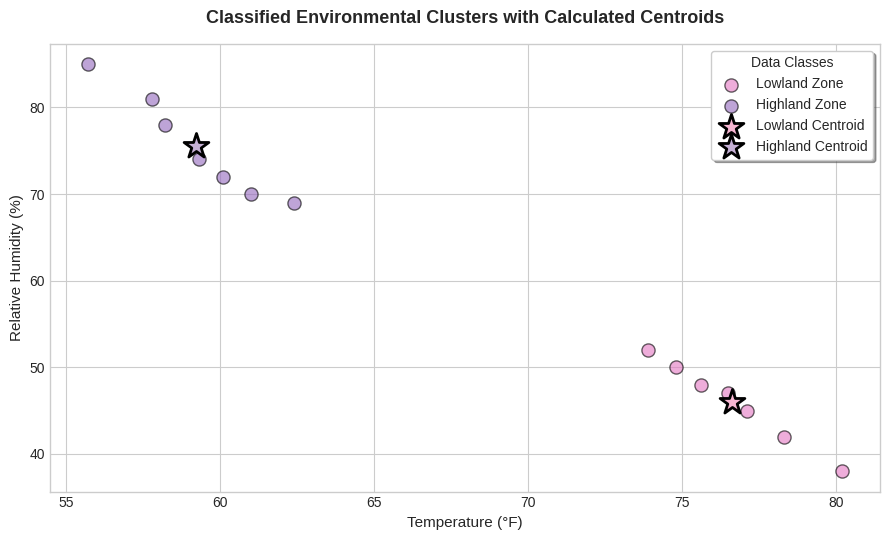

In [49]:
### Advanced Pattern (Highlighting Cluster Centroids)
#In clustering algorithms (like K-Means), researchers calculate the mathematical center point—the **centroid**—of each group. 

#We can calculate the mean coordinates for each cluster using `sum() / len()` (or NumPy) and plot a massive, highly visible marker right over the center point of our scatter configurations to anchor the visual analysis.

fig, ax = plt.subplots(figsize=(9, 5.5))

# Plot the base cluster point clouds from Step 3
ax.scatter(lowland_temp, lowland_humid, s=90, color='#e377c2', alpha=0.6, edgecolor='black', label='Lowland Zone')
ax.scatter(highland_temp, highland_humid, s=90, color='#9467bd', alpha=0.6, edgecolor='black', label='Highland Zone')

# ------------------------------------------------------------
# Addition: Calculate and plot mathematical Cluster Centers (Centroids)
# ------------------------------------------------------------
# Lowland Center Calculations
center_low_x = sum(lowland_temp) / len(lowland_temp)
center_low_y = sum(lowland_humid) / len(lowland_humid)

# Highland Center Calculations
center_high_x = sum(highland_temp) / len(highland_temp)
center_high_y = sum(highland_humid) / len(highland_humid)

# Plot Lowland Centroid as a massive pink star
ax.scatter(center_low_x, center_low_y, s=350, color='#f7b6d2', marker='*', 
           edgecolor='black', linewidth=2, label='Lowland Centroid')

# Plot Highland Centroid as a massive purple star
ax.scatter(center_high_x, center_high_y, s=350, color='#c5b0d5', marker='*', 
           edgecolor='black', linewidth=2, label='Highland Centroid')

# Final Formatting Polish
ax.set_title("Classified Environmental Clusters with Calculated Centroids", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Temperature (°F)", fontsize=11)
ax.set_ylabel("Relative Humidity (%)", fontsize=11)
ax.legend(loc='upper right', frameon=True, shadow=True, title="Data Classes")

plt.tight_layout()
plt.show()

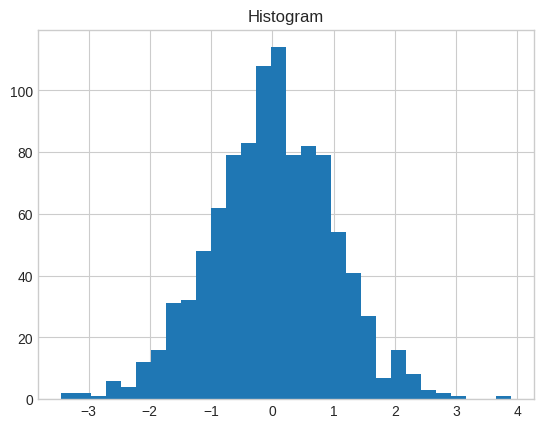

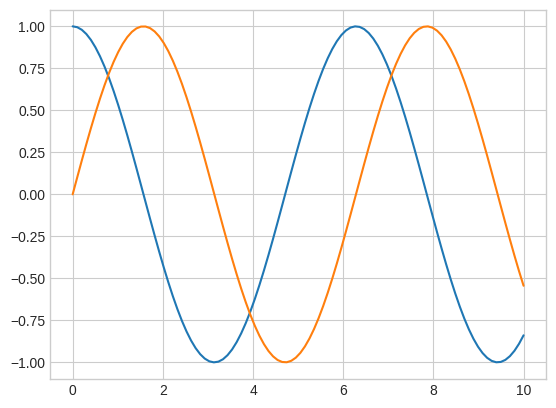

In [53]:
#Histogram: hist

data = np.random.randn(1000)

plt.hist(data, bins=30)
plt.title("Histogram")
plt.show()

# Saving a figure
x = np.linspace(0, 10, 100)
plt.plot(x, np.cos(x))  # try cos, tan
#plt.plot(x, np.sin(x))
#plt.savefig("plot.png", dpi=300)
plt.show()

